Aim:
 The aim of this project is to build a CNN-based model that can classify brain MRI images into tumor and non-tumor categories, and further identify specific types of brain tumors.

Dataset: https://www.kaggle.com/datasets/rishiksaisanthosh/brain-tumour-classification


Structure: The dataset contains brain MRI images categorized into glioma, meningioma, pituitary tumor, and no tumor. It is divided into training and testing sets.

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile

zip_ref = zipfile.ZipFile('/content/drive/MyDrive/AI_ASSIGNMENT/archive.zip')
zip_ref.extractall('/content/dataset')
zip_ref.close()

In [5]:
import zipfile

zip_ref = zipfile.ZipFile('/content/drive/MyDrive/AI_ASSIGNMENT/archive.zip')
zip_ref.extractall('/content/dataset')
zip_ref.close()

In [6]:
os.listdir('/content/dataset')

['BrainTumor_1']

In [7]:
os.listdir('/content/dataset/BrainTumor_1')

['Test', 'Train']

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

In [9]:
train_data = train_datagen.flow_from_directory(
    '/content/dataset/BrainTumor_1/Train',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

Found 22848 images belonging to 4 classes.


In [10]:
test_data = test_datagen.flow_from_directory(
    '/content/dataset/BrainTumor_1/Test',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

Found 1311 images belonging to 4 classes.


In [11]:
print(train_data.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


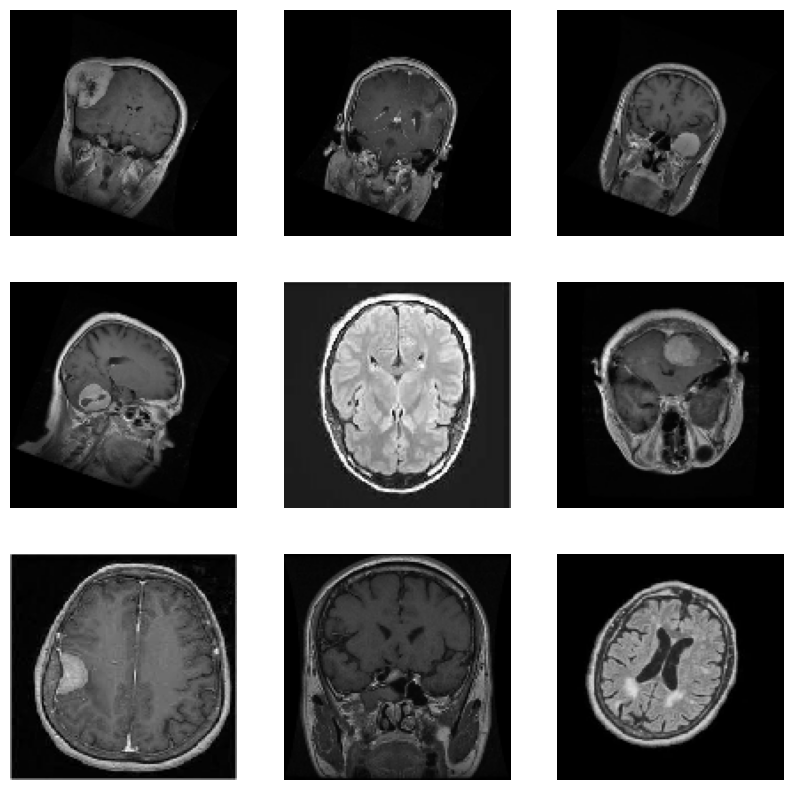

In [12]:
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.show()

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 709s 989ms/step - accuracy: 0.9672 - loss: 0.0942 - val_accuracy: 0.9580 - val_loss: 0.1178
Epoch 2/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 707s 989ms/step - accuracy: 0.9773 - loss: 0.0672 - val_accuracy: 0.9687 - val_loss: 0.0916
Epoch 3/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 706s 988ms/step - accuracy: 0.9812 - loss: 0.0561 - val_accuracy: 0.9558 - val_loss: 0.1329
Epoch 4/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 704s 986ms/step - accuracy: 0.9814 - loss: 0.0516 - val_accuracy: 0.9741 - val_loss: 0.0831
Epoch 5/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 703s 984ms/step - accuracy: 0.9842 - loss: 0.0442 - val_accuracy: 0.9680 - val_loss: 0.0679
Epoch 6/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 696s 974ms/step - accuracy: 0.9871 - loss: 0.0385 - val_accuracy: 0.9741 - val_loss: 0.0818
Epoch 7/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 701s 982ms/step - accuracy: 0.9870 - loss: 0.0371 - val_accuracy: 0.9634 - val_loss: 0.1655
Epoch 8/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 690s 967ms/step - accuracy: 0.9878 -

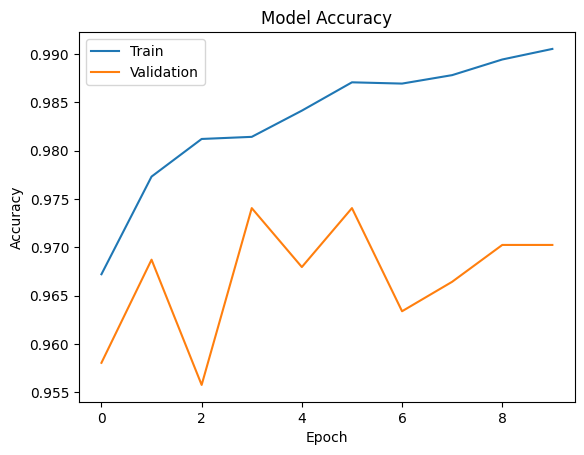

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.show()

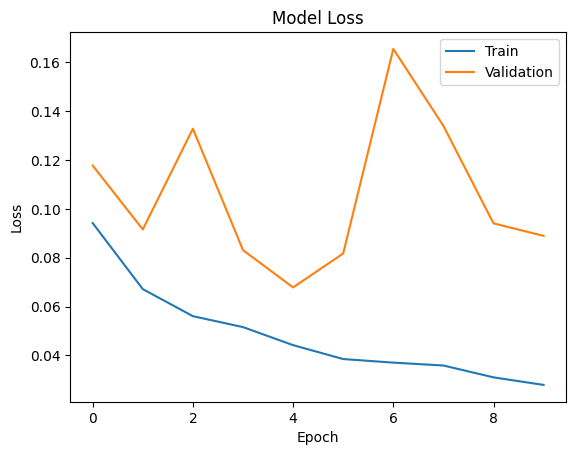

In [20]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

In [21]:
model.evaluate(test_data)

41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 257ms/step - accuracy: 0.9703 - loss: 0.0890


[0.08897148817777634, 0.970251739025116]

In [22]:
model.save("brain_tumor_model.h5")

In [23]:
model.save("brain_tumor_model.keras")

In [24]:
import numpy as np

Y_pred = model.predict(test_data)
y_pred = np.argmax(Y_pred, axis=1)

41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 321ms/step


In [25]:
y_true = test_data.classes

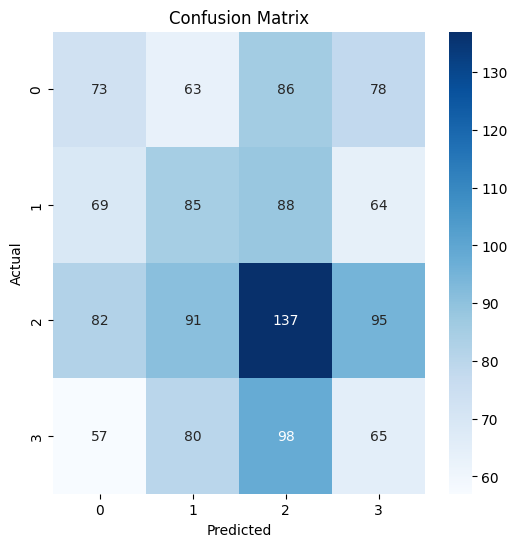

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=list(test_data.class_indices.keys())))

              precision    recall  f1-score   support

      glioma       0.26      0.24      0.25       300
  meningioma       0.27      0.28      0.27       306
     notumor       0.33      0.34      0.34       405
   pituitary       0.22      0.22      0.22       300

    accuracy                           0.27      1311
   macro avg       0.27      0.27      0.27      1311
weighted avg       0.27      0.27      0.27      1311



In [28]:
import pandas as pd

class_counts = pd.Series(train_data.classes).value_counts()

df = pd.DataFrame({
    'Class': list(train_data.class_indices.keys()),
    'Count': class_counts.sort_index().values
})

print(df)

        Class  Count
0      glioma   5284
1  meningioma   5356
2     notumor   6380
3   pituitary   5828


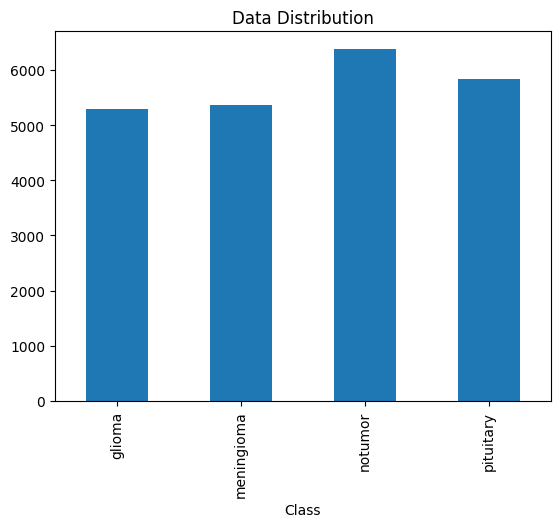

In [29]:
df.plot(kind='bar', x='Class', y='Count', legend=False)
plt.title('Data Distribution')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step


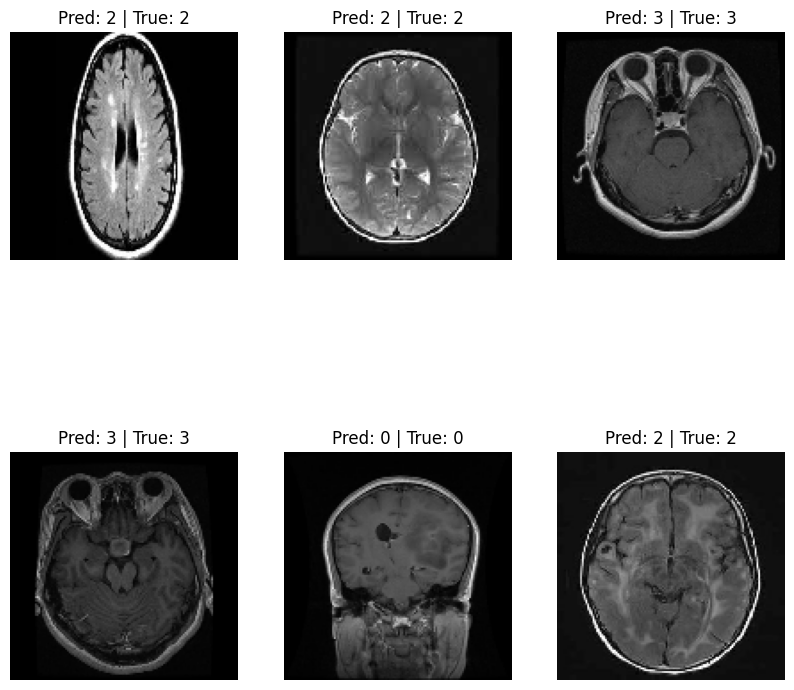

In [30]:
images, labels = next(test_data)

predictions = model.predict(images)

plt.figure(figsize=(10,10))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])

    pred_label = np.argmax(predictions[i])
    true_label = np.argmax(labels[i])

    plt.title(f"Pred: {pred_label} | True: {true_label}")
    plt.axis('off')

plt.show()